In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install tqdm pymannkendall

In [3]:
import numpy as np
import pandas as pd
import pytz
import os
import requests
from io import StringIO
from scipy import stats
from scipy.stats import gaussian_kde, norm
from sklearn.linear_model import TheilSenRegressor
from sklearn.model_selection import LeaveOneOut
import statsmodels.api as sm
import pymannkendall as mk
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [4]:
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# ============================================================
# PARAMÈTRES MODIFIABLES
# ============================================================
params = {
    # Seuils de filtrage
    'SUN_ALT': -18,                      # altitude solaire pour la nuit astronomique
    'MOON_ILLUM': 10,                    # % illumination max
    'B_ZEN_MIN': 20,                     # éloignement minimal du plan galactique (°)
    'DELTA_T': 20,                       # seuil delta_T (°C) pour suspicion de nuage
    'DELTA_T_STD_WINDOW': '30min',       # fenêtre glissante stabilité
    'DELTA_T_STD_THRESH': 2,             # écart‑type max sur la fenêtre
    'MIN_MEASURES_NIGHT': 50,            # nombre minimal de mesures par nuit
    'NSB_MIN_THRESHOLD': None,           # seuil plancher de NSB (ex: 12 mag) ; None = désactivé

    # Laser
    'LASER_WINDOWS': [(0, 20, 23), (1, 20, 23)],  # (jour semaine 0=lundi, début h, fin h) en heure locale
    'LASER_SIGMA': 5,                    # seuil de détection des pics (σ)

    # Bootstrap
    'BOOTSTRAP_ITERS': 500,              # répliques bootstrap (tendances)

    # Instrumental
    'NSB_POINT_ERROR': 0.06,             # erreur de mesure TESS‑W (mag)

    # Temps
    'TIMEZONE': 'Indian/Reunion',        # fuseau horaire (UTC+4)
    'GAP_TOLERANCE': pd.Timedelta('30min'),  # écart max pour segmenter les nuits

    # Seed
    'SEED': 42,

    # Fichier d’entrée
    'CSV_PATH': '/content/drive/MyDrive/Research2026/data/raw/ID004.csv',
    # Fichier F10.7 (None pour téléchargement automatique)
    'F107_FILE':'/content/drive/MyDrive/Research2026/data/external/F107_fluxtable.txt',
}

np.random.seed(params['SEED'])

In [5]:
# ## 2. Fonctions utilitaires (chargement, filtrage, agrégation)

def load_data(csv_path):
    """Lit le CSV TESS‑W, parse la date UTC, nettoie les NaN/inf."""
    df = pd.read_csv(csv_path)
    df.columns = [c.strip().upper() for c in df.columns]
    required_all = ['UTC_DATE', 'NSB', 'ALT_SUN', 'ALT_MOON', 'ILLUMOON',
                    'B_ZEN', 'T_AMB', 'T_SKY']
    missing = set(required_all) - set(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes : {missing}")
    df['UTC_DATE'] = pd.to_datetime(df['UTC_DATE'])
    df = df.set_index('UTC_DATE').sort_index()
    # Colonnes de mesures (sans UTC_DATE)
    required_measures = ['NSB', 'ALT_SUN', 'ALT_MOON', 'ILLUMOON',
                         'B_ZEN', 'T_AMB', 'T_SKY']
    sub = df[required_measures].copy()
    sub.replace([np.inf, -np.inf], np.nan, inplace=True)
    nan_mask = sub.isna().any(axis=1)
    print(f"Lignes supprimées (NaN/inf) : {nan_mask.sum()} / {len(df)}")
    df = df.loc[~nan_mask]
    df['delta_T'] = df['T_AMB'] - df['T_SKY']
    return df

def define_nights(df, sun_alt, gap_tol, tz_name):
    """Identifie les nuits astronomiques et attribue un night_id + night_date locale."""
    tz = pytz.timezone(tz_name)
    night_mask = df['ALT_SUN'] < sun_alt
    df_night = df[night_mask].copy()
    groups = (df_night.index.to_series().diff() > gap_tol).cumsum()
    df_night['night_id'] = groups.values
    # Heure locale du début de chaque nuit
    starts = df_night.groupby('night_id').apply(lambda g: g.index[0])
    starts_local = starts.dt.tz_localize('UTC').dt.tz_convert(tz)
    df_night['night_date'] = df_night['night_id'].map(starts_local.dt.date)
    # Fusion avec le DataFrame complet
    df_out = df.copy()
    df_out['night_id'] = np.nan
    df_out['night_date'] = pd.NaT
    df_out.loc[df_night.index, 'night_id'] = df_night['night_id']
    df_out.loc[df_night.index, 'night_date'] = df_night['night_date']
    # Ajout des heures locales (utiles pour laser, minuit, etc.)
    df_out['local_datetime'] = df_out.index.tz_localize('UTC').tz_convert(tz)
    df_out['local_time'] = df_out['local_datetime'].dt.time
    return df_out

def filter_sequence(df):
    """
    Applique les filtres séquentiels.
    Retourne un masque booléen (True = conservé).
    """
    # 1) Nuit astronomique (Soleil sous le seuil)
    mask = df['ALT_SUN'] < params['SUN_ALT']
    print(f"Après filtre Nuit astronomique : {mask.sum()}")

    # 2) Lune
    moon_ok = (df['ALT_MOON'] < 0) & (df['ILLUMOON'] <= params['MOON_ILLUM'])
    mask &= moon_ok
    print(f"Après filtre Lune : {mask.sum()}")

    # 3) Voie lactée
    mw_ok = np.abs(df['B_ZEN']) >= params['B_ZEN_MIN']
    mask &= mw_ok
    print(f"Après filtre Voie lactée : {mask.sum()}")

    # 4) Nuages (delta_T ET stabilité) -> on EXCLUT les mesures suspectes

    cloud_threshold = df['delta_T'] >= params['DELTA_T']
    roll_std = df['delta_T'].rolling(params['DELTA_T_STD_WINDOW'], center=True, min_periods=5).std()
    stable = roll_std <= params['DELTA_T_STD_THRESH']
    cloud_ok = cloud_threshold & stable   # on retire les nuages probables
    mask &= cloud_ok
    print(f"Après filtre Nuages : {mask.sum()}")

    # 5) Laser : exclusion des créneaux planifiés cas spécifique pour le site de l'OBS au Maido
    tz = pytz.timezone(params['TIMEZONE'])
    local_dt = df['local_datetime']
    weekday = local_dt.dt.weekday          # 0 = lundi
    hour = local_dt.dt.hour + local_dt.dt.minute/60 + local_dt.dt.second/3600

    in_scheduled = pd.Series(False, index=df.index)
    for (day, start_h, end_h) in params['LASER_WINDOWS']:
        # Gestion du chevauchement de minuit
        if start_h < end_h:
            window = (weekday == day) & (hour >= start_h) & (hour < end_h)
        else:
            window = ((weekday == day) & (hour >= start_h)) | \
                    ((weekday == (day+1)%7) & (hour < end_h))
        in_scheduled |= window

    scheduled_ok = ~in_scheduled
    mask &= scheduled_ok
    print(f"Après filtre Laser (créneaux) : {mask.sum()}")
    return mask

def compute_mode_kde(series, bw_method='scott'):
    """Mode par KDE (règle de Scott)."""
    if len(series) < 2:
        return np.nan
    data = series.dropna().values
    kde = gaussian_kde(data, bw_method=bw_method)
    grid = np.linspace(data.min(), data.max(), 1000)
    density = kde(grid)
    return grid[np.argmax(density)]

def aggregate_nights(df):
    """
    Agrège les mesures filtrées par nuit (au moins MIN_MEASURES_NIGHT).
    Retourne un DataFrame indexé par night_id.
    """
    group = df.groupby('night_id')
    agg = []
    for nid, grp in group:
        n = len(grp)
        if n < params['MIN_MEASURES_NIGHT']:
            continue
        median_nsb = grp['NSB'].median()
        mode_nsb = compute_mode_kde(grp['NSB'])
        iqr_nsb = grp['NSB'].quantile(0.75) - grp['NSB'].quantile(0.25)
        mean_bzen = grp['B_ZEN'].mean()
        mean_deltaT = grp['delta_T'].mean()
        night_date = grp['night_date'].iloc[0]
        local_dt = grp['local_datetime'].iloc[0]
        year_dec = local_dt.year + (local_dt.dayofyear - 1) / 365.25
        month = local_dt.month
        agg.append({
            'night_id': nid,
            'night_date': night_date,
            'median_NSB': median_nsb,
            'mode_NSB': mode_nsb,
            'IQR_NSB': iqr_nsb,
            'n_measures': n,
            'year_decimal': year_dec,
            'month': month,
            'mean_B_ZEN': mean_bzen,
            'mean_deltaT': mean_deltaT,
        })
    df_agg = pd.DataFrame(agg)
    if len(df_agg) == 0:
        return df_agg  # vide
    return df_agg.set_index('night_id')

In [6]:
# ## 3. Chargement, définition des nuits, filtrage, agrégation

print("Chargement des données...")
df = load_data(params['CSV_PATH'])
print(f"Données chargées : {len(df)} enregistrements du {df.index.min()} au {df.index.max()}")

df = define_nights(df, params['SUN_ALT'], params['GAP_TOLERANCE'], params['TIMEZONE'])
print(f"Nuits astronomiques détectées : {df['night_id'].nunique()}")

filter_mask = filter_sequence(df)
df_filtered = df[filter_mask].copy()
print(f"Mesures totales après filtrage : {len(df_filtered)}")

aggregated = aggregate_nights(df_filtered)
print(f"Nuits conservées après agrégation : {len(aggregated)}")

Chargement des données...
Lignes supprimées (NaN/inf) : 4 / 464946
Données chargées : 464942 enregistrements du 2022-05-24 13:48:42 au 2025-04-23 08:55:49
Nuits astronomiques détectées : 998
Après filtre Nuit astronomique : 329455
Après filtre Lune : 166422
Après filtre Voie lactée : 120430
Après filtre Nuages : 62330
Après filtre Laser (créneaux) : 57441
Mesures totales après filtrage : 57441
Nuits conservées après agrégation : 247


In [7]:
# ## 4. Fenêtre minuit local (fusionnée à aggregated)

def midnight_window(df_filt):
    local_hour = df_filt['local_datetime'].dt.hour + df_filt['local_datetime'].dt.minute/60
    midnight_mask = (local_hour >= 23.5) | (local_hour < 0.5)
    df_mid = df_filt[midnight_mask].copy()
    mid_agg = df_mid.groupby('night_id').agg(
        midnight_mean_NSB=('NSB', 'mean'),
        midnight_std_NSB=('NSB', 'std'),
        midnight_n=('NSB', 'count')
    ).reset_index()
    return mid_agg

midnight_stats = midnight_window(df_filtered)
aggregated = aggregated.merge(midnight_stats, on='night_id', how='left')
# Réindexer pour que l'index reste night_id
aggregated = aggregated.set_index('night_id')

In [8]:
# ## 5. Analyses de tendance (LOO‑CV – quelques minutes)

def theil_sen_bootstrap(x, y, n_iter=500, alpha=0.05):
    slopes = []
    n = len(x)
    idx = np.arange(n)
    rng = np.random.RandomState(params['SEED'])
    for _ in range(n_iter):
        boot_idx = rng.choice(idx, size=n, replace=True)
        x_boot = x[boot_idx]
        y_boot = y[boot_idx]
        reg = TheilSenRegressor(random_state=params['SEED']).fit(x_boot.reshape(-1,1), y_boot)
        slopes.append(reg.coef_[0])
    slope_est = np.median(slopes)
    ci_low, ci_high = np.percentile(slopes, [100*alpha/2, 100*(1-alpha/2)])
    return slope_est, ci_low, ci_high, slopes

def compute_trends(df_agg, alpha=0.05):
    x = df_agg['year_decimal'].values
    y = df_agg['median_NSB'].values
    n = len(x)
    if n < 5:
        print("Trop peu de nuits pour l'analyse de tendance.")
        return None

    # Theil‑Sen avec bootstrap
    ts_slope, ts_lo, ts_hi, _ = theil_sen_bootstrap(x, y, n_iter=params['BOOTSTRAP_ITERS'], alpha=alpha)

    # OLS
    X = sm.add_constant(x)
    ols_model = sm.OLS(y, X).fit()
    ols_slope = ols_model.params[1]
    ols_pval = ols_model.pvalues[1]
    ols_ci = ols_model.conf_int(alpha=alpha)         # tableau NumPy 2x2
    ols_ci_slope = (ols_ci[1, 0], ols_ci[1, 1])      # (borne inf pente, borne sup pente)
    # RLM Huber
    rlm_model = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
    rlm_slope = rlm_model.params[1]
    rlm_cov = rlm_model.bcov_scaled
    if rlm_cov is not None:
        rlm_se = np.sqrt(rlm_cov[1,1])
        rlm_z = rlm_slope / rlm_se
        rlm_pval = 2*(1 - norm.cdf(np.abs(rlm_z)))
    else:
        rlm_se = np.nan
        rlm_pval = np.nan
    z_alpha = norm.ppf(1-alpha/2)
    rlm_ci = (rlm_slope - z_alpha*rlm_se, rlm_slope + z_alpha*rlm_se)

    # Mann‑Kendall
    mk_result = mk.original_test(y)

    # LOO‑CV
    loo = LeaveOneOut()
    loo_rmse = {}
    constant_pred = np.full_like(y, np.mean(y))
    loo_rmse['Constante'] = np.sqrt(np.mean((y - constant_pred)**2))

    for name in ['OLS', 'RLM']:
        errs = []
        for train_idx, test_idx in loo.split(x):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            if name == 'OLS':
                fit = sm.OLS(y_train, X_train).fit()
            else:
                fit = sm.RLM(y_train, X_train, M=sm.robust.norms.HuberT()).fit()
            pred = fit.predict(X_test)
            errs.append((pred[0] - y_test[0])**2)
        loo_rmse[name] = np.sqrt(np.mean(errs))

    ts_errs = []
    for train_idx, test_idx in loo.split(x):
        X_train, X_test = x[train_idx].reshape(-1,1), x[test_idx].reshape(-1,1)
        y_train, y_test = y[train_idx], y[test_idx]
        reg = TheilSenRegressor(random_state=params['SEED']).fit(X_train, y_train)
        pred = reg.predict(X_test)
        ts_errs.append((pred[0] - y_test[0])**2)
    loo_rmse['Theil‐Sen'] = np.sqrt(np.mean(ts_errs))

    def slope_to_percent(slope):
        return (10**(-0.4*slope) - 1) * 100

    return {
        'n_nights': n,
        'Theil_Sen': {
            'slope_mag_yr': ts_slope,
            'slope_pct_yr': slope_to_percent(ts_slope),
            'CI95_mag': (ts_lo, ts_hi),
            'CI95_pct': (slope_to_percent(ts_lo), slope_to_percent(ts_hi)),
        },
        'OLS': {
            'slope_mag_yr': ols_slope,
            'slope_pct_yr': slope_to_percent(ols_slope),
            'p_value': ols_pval,
            'CI95_mag': ols_ci_slope,
            'CI95_pct': (slope_to_percent(ols_ci_slope[0]), slope_to_percent(ols_ci_slope[1])),
        },
        'RLM': {
            'slope_mag_yr': rlm_slope,
            'slope_pct_yr': slope_to_percent(rlm_slope),
            'p_value': rlm_pval,
            'CI95_mag': rlm_ci,
            'CI95_pct': (slope_to_percent(rlm_ci[0]), slope_to_percent(rlm_ci[1])),
        },
        'Mann_Kendall': {
            'trend': mk_result.trend,
            'h': mk_result.h,
            'p': mk_result.p,
            'z': mk_result.z,
        },
        'LOO_CV_RMSE': loo_rmse,
    }

print("Calcul des tendances (peut durer quelques minutes)...")
import time
start_t = time.time()
trend_results = compute_trends(aggregated)
print(f"Terminé en {time.time()-start_t:.1f} s")

# Résumé
print("\n=== Résumé des tendances ===")
for k in ['Theil_Sen','OLS','RLM']:
    tr = trend_results[k]
    p_val = tr.get('p_value', None)
    p_str = f"{p_val:.4f}" if p_val is not None and not np.isnan(p_val) else 'N/A'
    print(f"{k}: pente {tr['slope_mag_yr']:.4f} mag/an, IC95 [{tr['CI95_mag'][0]:.4f}, {tr['CI95_mag'][1]:.4f}], "
          f"var. rad. {tr['slope_pct_yr']:.2f} %/an, p={p_str}")
mk_r = trend_results['Mann_Kendall']
print(f"Mann‑Kendall: tendance='{mk_r['trend']}', p={mk_r['p']:.4f}")
print("LOO‑CV RMSE (mag) :", trend_results['LOO_CV_RMSE'])

Calcul des tendances (peut durer quelques minutes)...
Terminé en 560.4 s

=== Résumé des tendances ===
Theil_Sen: pente 0.0137 mag/an, IC95 [-0.0000, 0.0403], var. rad. -1.25 %/an, p=N/A
OLS: pente 0.0028 mag/an, IC95 [-0.0210, 0.0265], var. rad. -0.25 %/an, p=0.8189
RLM: pente 0.0130 mag/an, IC95 [-0.0096, 0.0355], var. rad. -1.19 %/an, p=0.2602
Mann‑Kendall: tendance='no trend', p=0.1041
LOO‑CV RMSE (mag) : {'Constante': np.float64(0.1492848339154142), 'OLS': np.float64(0.1505111154146627), 'RLM': np.float64(0.15103201035876582), 'Theil‐Sen': np.float64(0.17426036497642527)}


In [12]:
# ## 6. Détection des outliers (résidus OLS)

def detect_outliers(df_agg, trend_results):
    x = df_agg['year_decimal'].values
    y = df_agg['median_NSB'].values
    X = sm.add_constant(x)
    ols_fit = sm.OLS(y, X).fit()
    residuals = ols_fit.resid
    # MAD
    median_res = np.median(residuals)
    mad = np.median(np.abs(residuals - median_res))
    robust_z = 0.6745 * (residuals - median_res) / mad
    outliers_z = np.abs(robust_z) > 3.5
    # IQR
    q1, q3 = np.percentile(residuals, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers_iqr = (residuals < lower) | (residuals > upper)
    outliers = outliers_z | outliers_iqr
    outlier_ids = df_agg.index[outliers].tolist()
    print(f"Outliers (z>3.5 ou IQR) : {len(outlier_ids)}")
    print("Nuits :", outlier_ids)
    return outlier_ids, residuals

outlier_ids, ols_residuals = detect_outliers(aggregated, trend_results)

outlier_nights = aggregated.loc[outlier_ids]
print("\nTableau listant les nuits aberrantes\n")
print(outlier_nights[['night_date', 'median_NSB', 'mean_deltaT']])


Outliers (z>3.5 ou IQR) : 3
Nuits : [696.0, 719.0, 720.0]

Tableau listant les nuits aberrantes

         night_date  median_NSB  mean_deltaT
night_id                                    
696.0    2024-05-29   20.839020    24.291118
719.0    2024-06-24   20.707254    36.988491
720.0    2024-06-25   20.398855    32.094038


In [13]:
# ## 7. Corrélations (NSB vs B_ZEN, NSB vs F10.7)


def effective_sample_size_correlation(x, y):
    n = len(x)
    if n < 4:
        return n
    x0, x1 = x[:-1], x[1:]
    y0, y1 = y[:-1], y[1:]
    r1_x = np.corrcoef(x0, x1)[0,1] if np.std(x0)>0 and np.std(x1)>0 else 0
    r1_y = np.corrcoef(y0, y1)[0,1] if np.std(y0)>0 and np.std(y1)>0 else 0
    denom = 1 + r1_x * r1_y
    if denom == 0:
        return n
    return max(3, n * (1 - r1_x * r1_y) / denom)

# Préparer l'agrégation mensuelle
aggregated['year_month'] = pd.to_datetime(aggregated['night_date']).dt.to_period('M')
monthly = aggregated.groupby('year_month').agg(
    monthly_median_NSB=('median_NSB', 'mean'),
    monthly_mean_BZEN=('mean_B_ZEN', 'mean')
).dropna()

# 7.1 NSB vs B_ZEN
r_bzen, p_bzen_raw = stats.pearsonr(monthly['monthly_median_NSB'], monthly['monthly_mean_BZEN'])
neff_bzen = effective_sample_size_correlation(monthly['monthly_median_NSB'].values,
                                              monthly['monthly_mean_BZEN'].values)
t_bzen = r_bzen * np.sqrt((neff_bzen - 2) / (1 - r_bzen**2))
p_bzen_corr = 2 * stats.t.sf(np.abs(t_bzen), df=neff_bzen - 2)
print(f"NSB vs B_ZEN (mensuel) : r = {r_bzen:.3f}, p brute = {p_bzen_raw:.4f}, Neff = {neff_bzen:.1f}, p corrigée = {p_bzen_corr:.4f}")

# 7.2 NSB vs F10.7
try:
    if params['F107_FILE'] and os.path.exists(params['F107_FILE']):
        # Lecture avec agrégation journalière
        f107_df = pd.read_csv(params['F107_FILE'], sep=r'\s+', header=0)
        # Reconstruire la datetime UTC
        f107_df['fluxdate_str'] = f107_df['fluxdate'].astype(str)
        f107_df['fluxtime_str'] = f107_df['fluxtime'].astype(str).str.zfill(6)
        f107_df['datetime_utc'] = pd.to_datetime(
            f107_df['fluxdate_str'] + f107_df['fluxtime_str'],
            format='%Y%m%d%H%M%S', errors='coerce')
        f107_df = f107_df.dropna(subset=['datetime_utc'])
        # Colonne de flux (ajusté de préférence)
        flux_col = 'fluxadjflux' if 'fluxadjflux' in f107_df.columns else 'fluxobsflux'
        f107_df[flux_col] = pd.to_numeric(f107_df[flux_col], errors='coerce')
        f107_df = f107_df.dropna(subset=[flux_col])
        # Agrégation journalière : moyenne des mesures du jour
        f107_df['date'] = f107_df['datetime_utc'].dt.date
        f107_daily = f107_df.groupby('date')[flux_col].mean()
        f107_series = f107_daily.copy()
        f107_series.index = pd.to_datetime(f107_series.index)
        f107_series = f107_series.sort_index()
    else:
        # fallback (non implémenté ici – placeholder)
        raise ValueError("Fichier F10.7 non trouvé.")

    # Fusion avec les nuits
    night_dates = pd.to_datetime(aggregated['night_date'])
    f107_daily = f107_series.reindex(night_dates, method='nearest', tolerance=pd.Timedelta('1D'))
    aggregated['F10.7'] = f107_daily.values

    # Corrélation mensuelle
    monthly_f107 = aggregated.groupby('year_month')['F10.7'].mean()
    monthly_nsb_f107 = aggregated.groupby('year_month')['median_NSB'].mean()
    valid = monthly_nsb_f107.notna() & monthly_f107.notna()
    nsb_m = monthly_nsb_f107[valid]
    f107_m = monthly_f107[valid]
    if len(nsb_m) > 3:
        r_f107, p_f107_raw = stats.pearsonr(nsb_m, f107_m)
        neff_f107 = effective_sample_size_correlation(nsb_m.values, f107_m.values)
        t_f107 = r_f107 * np.sqrt((neff_f107 - 2) / (1 - r_f107**2))
        p_f107_corr = 2 * stats.t.sf(np.abs(t_f107), df=neff_f107 - 2)
        print(f"NSB vs F10.7 (mensuel) : r = {r_f107:.3f}, p brute = {p_f107_raw:.4f}, Neff = {neff_f107:.1f}, p corrigée = {p_f107_corr:.4f}")
    else:
        print("Pas assez de données F10.7.")
        r_f107 = np.nan
except Exception as e:
    print(f"Erreur F10.7 : {e}")
    r_f107 = np.nan

# Puissance statistique (Cohen, 1988)
r_target = 0.3
z_alpha = stats.norm.ppf(1 - 0.05/2)
z_beta = stats.norm.ppf(0.8)
n_required = ((z_alpha + z_beta) / (0.5 * np.log((1+r_target)/(1-r_target))))**2 + 3
print(f"\nPour r={r_target} à 80% puissance, ~{int(np.ceil(n_required))} points nécessaires.")

NSB vs B_ZEN (mensuel) : r = -0.518, p brute = 0.0113, Neff = 13.3, p corrigée = 0.0660
NSB vs F10.7 (mensuel) : r = 0.001, p brute = 0.9967, Neff = 12.5, p corrigée = 0.9977

Pour r=0.3 à 80% puissance, ~85 points nécessaires.


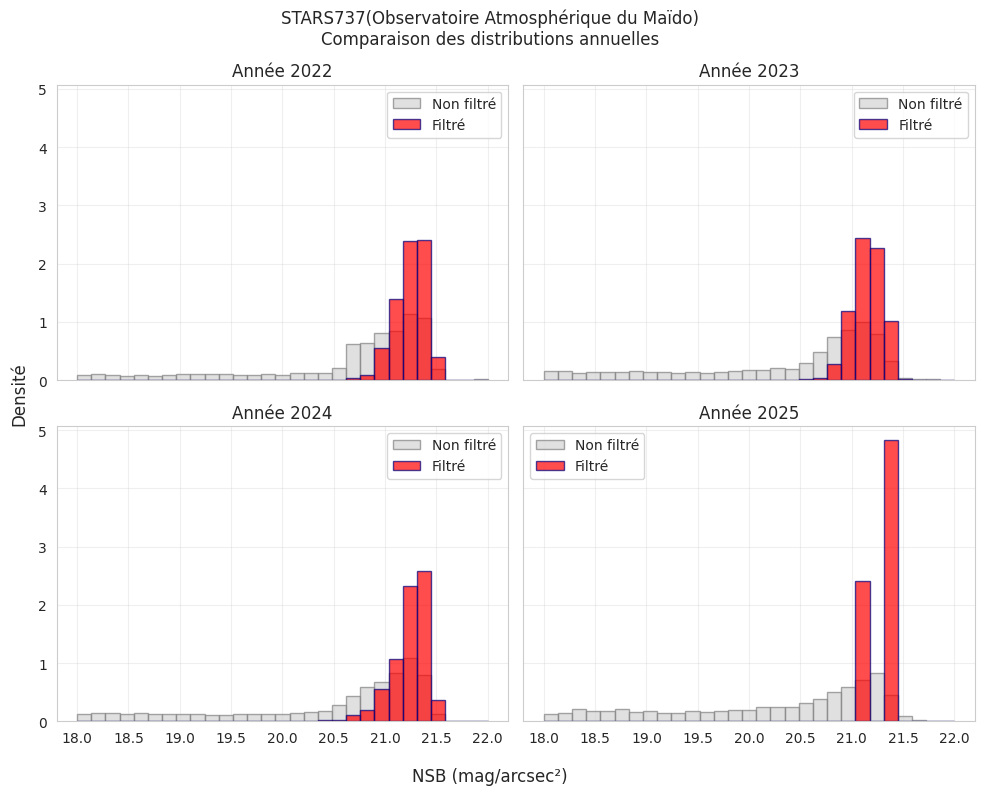

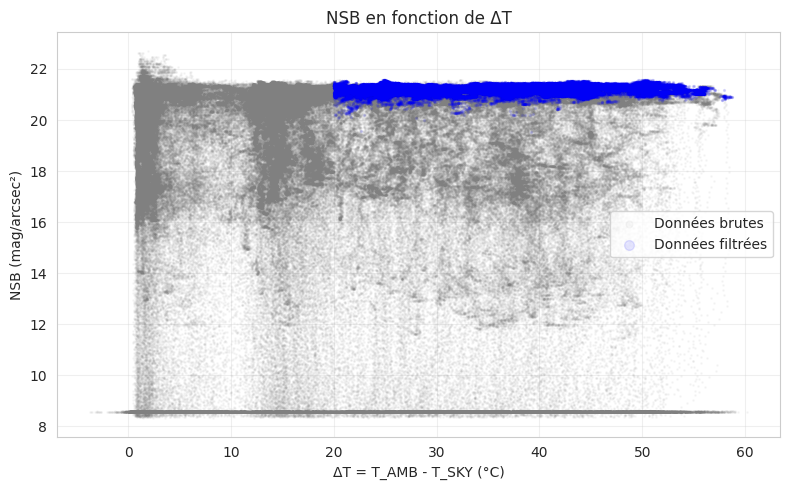

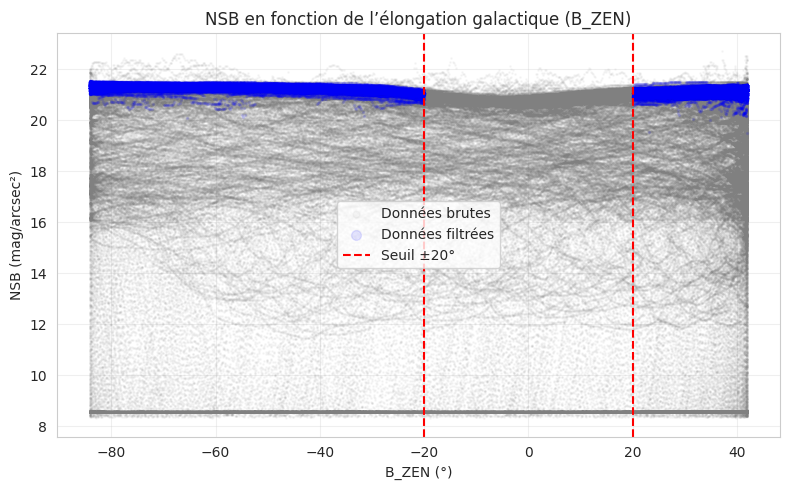

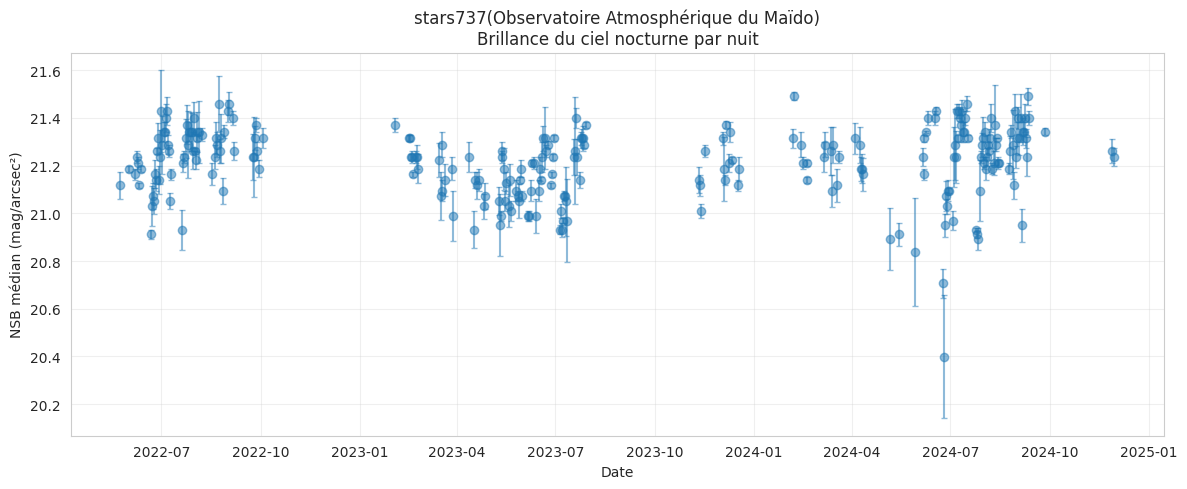

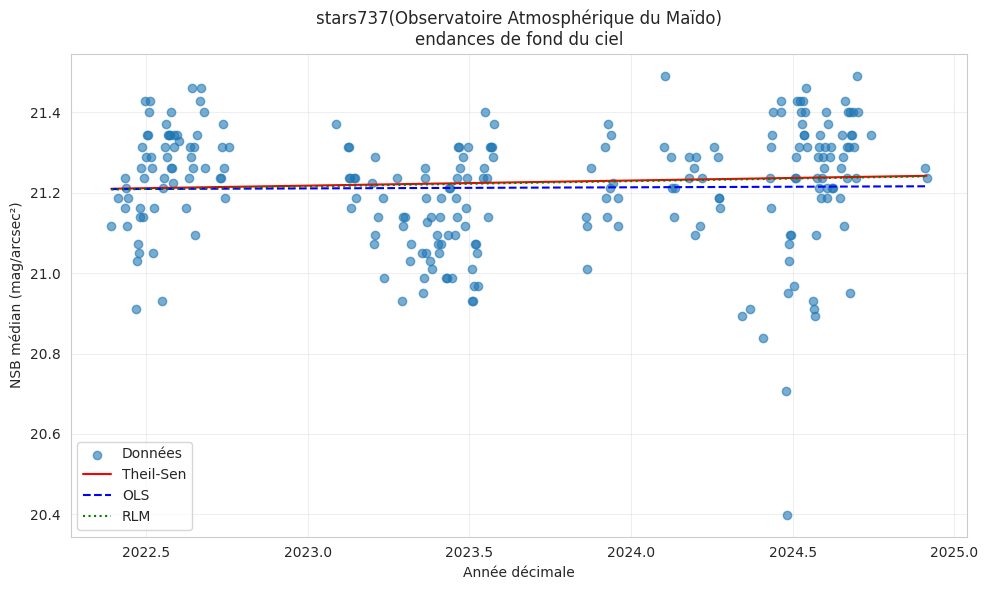

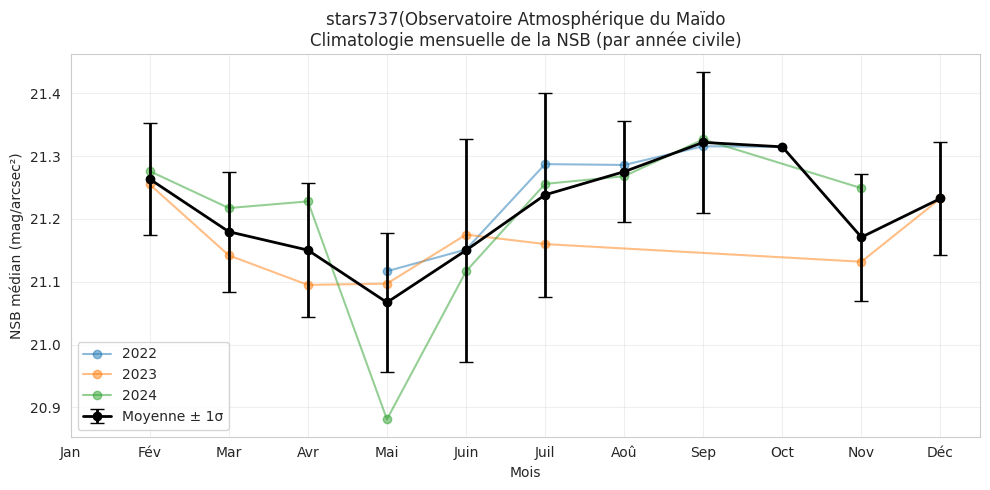

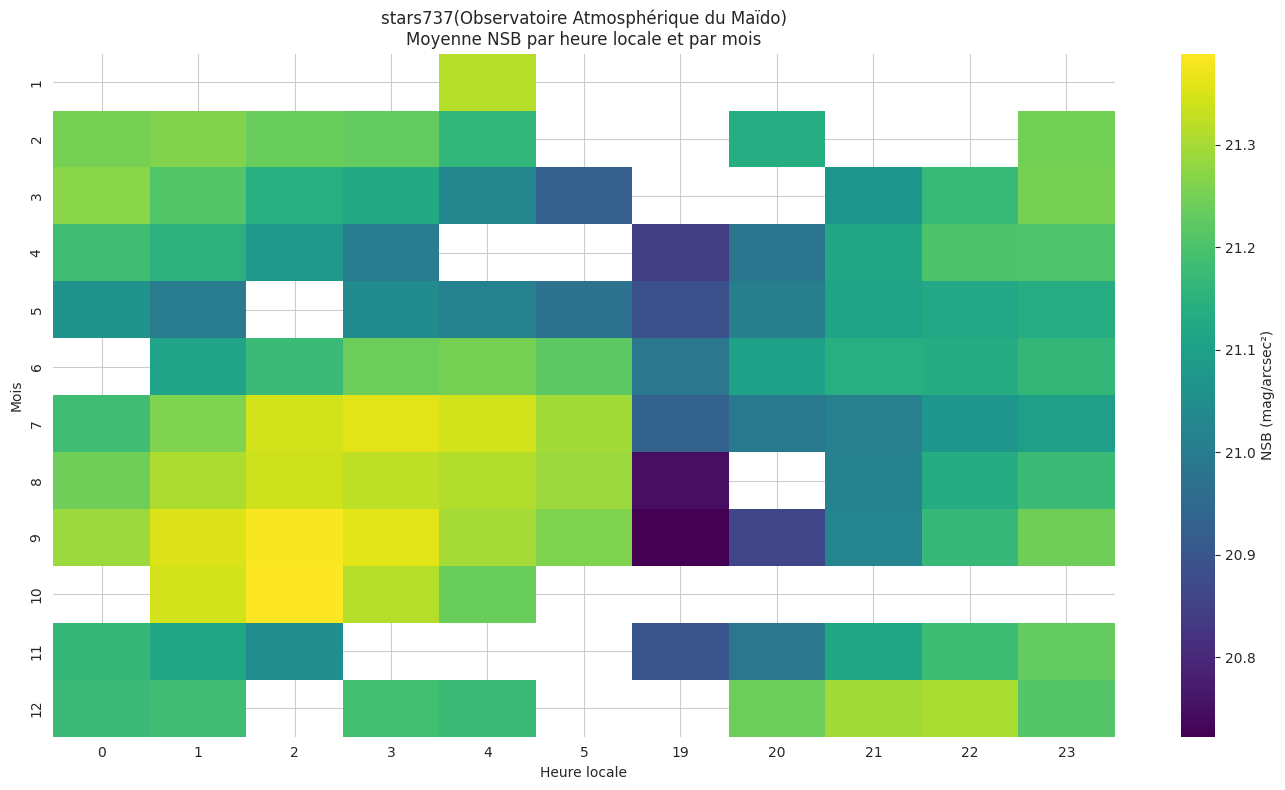

<Figure size 1200x600 with 0 Axes>

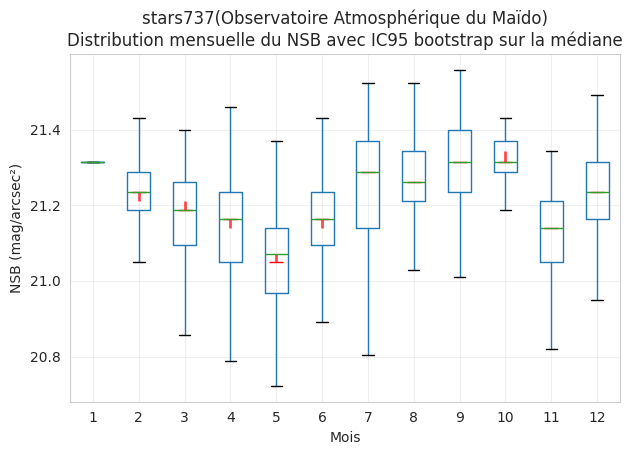

In [14]:
# ## 8. Visualisations


!mkdir -p figures

# ### 8.1 Distribution annuelle de la NSB avant/après filtrage.

def plot_data_distribution(df, df_filtered):
    # Ajouter l'année
    df['annee'] = pd.to_datetime(df['LOC_DATE']).dt.year
    df_filtered['annee'] = pd.to_datetime(df_filtered['LOC_DATE']).dt.year

    annees = sorted(set(df['annee'].unique()) & set(df_filtered['annee'].unique()))
    if not annees:
        print("Aucune année commune pour le graphique.")
        return

    # Mise en page 2x2
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True, sharex=True)
    axes = axes.flatten()   # permet d'itérer facilement

    bins = np.linspace(18, 22, 30)

    for i, annee in enumerate(annees):
        if i >= 4:   # sécurité si plus de 4 années
            print(f"Année {int(annee)} ignorée (max 4 panneaux)")
            break

        data_brut = df[df['annee'] == annee]['NSB'].dropna()
        data_filtre = df_filtered[df_filtered['annee'] == annee]['NSB'].dropna()

        axes[i].hist(data_brut, bins=bins, color='lightgrey', edgecolor='gray',
                     alpha=0.7, label='Non filtré', density=True)
        axes[i].hist(data_filtre, bins=bins, color='red', edgecolor='navy',
                     alpha=0.7, label='Filtré', density=True)
        axes[i].set_title(f'Année {int(annee)}')
        axes[i].grid(alpha=0.3)
        axes[i].legend()

    # Masquer les panneaux inutilisés
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    # Étiquettes communes
    fig.supxlabel('NSB (mag/arcsec²)')
    fig.supylabel('Densité')
    fig.suptitle('STARS737(Observatoire Atmosphérique du Maïdo)\nComparaison des distributions annuelles')
    plt.savefig('figures/annualdatadistribution.png')
    plt.tight_layout()
    plt.show()

# Appel
plot_data_distribution(df, df_filtered)

# ### 8.2 Distribution NSB vs Delta T

plt.figure(figsize=(8, 5))
# Données brutes (tout le DataFrame df)
plt.scatter(df['delta_T'], df['NSB'], alpha=0.05, s=1, color='gray', label='Données brutes')
# Données filtrées
plt.scatter(df_filtered['delta_T'], df_filtered['NSB'], alpha=0.1, s=2, color='blue', label='Données filtrées')
plt.xlabel('ΔT = T_AMB - T_SKY (°C)')
plt.ylabel('NSB (mag/arcsec²)')
plt.title('NSB en fonction de ΔT')
plt.grid(True, alpha=0.3)
plt.legend(markerscale=5)
plt.tight_layout()
plt.savefig('figures/nsb_vs_deltaT.png')
plt.show()

# ### 8.3 Distribution NSB vs B_ZEN

plt.figure(figsize=(8, 5))
# Brutes
plt.scatter(df['B_ZEN'], df['NSB'], alpha=0.05, s=1, color='gray', label='Données brutes')
# Filtrées
plt.scatter(df_filtered['B_ZEN'], df_filtered['NSB'], alpha=0.1, s=2, color='blue', label='Données filtrées')
plt.xlabel('B_ZEN (°)')
plt.ylabel('NSB (mag/arcsec²)')
plt.title('NSB en fonction de l’élongation galactique (B_ZEN)')
plt.grid(True, alpha=0.3)
# Seuils Voie lactée
plt.axvline(x=params['B_ZEN_MIN'], color='red', linestyle='--', label=f'Seuil ±{params["B_ZEN_MIN"]}°')
plt.axvline(x=-params['B_ZEN_MIN'], color='red', linestyle='--')
plt.legend(markerscale=5)
plt.tight_layout()
plt.savefig('figures/nsb_vs_bzen.png')
plt.show()

# ### 8.4 Série temporelle par nuit

plt.figure(figsize=(12, 5))
plt.errorbar(aggregated['night_date'], aggregated['median_NSB'],
             yerr=aggregated['IQR_NSB']/2, fmt='o', alpha=0.5, capsize=2)
plt.xlabel('Date')
plt.ylabel('NSB médian (mag/arcsec²)')
plt.title('stars737(Observatoire Atmosphérique du Maïdo)\nBrillance du ciel nocturne par nuit')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/serie_temporelle_nuit.png')
plt.show()

# ### 8.5 Comparaison des tendances Theil‑Sen / OLS / RLM

x_vals = aggregated['year_decimal'].values
y_vals = aggregated['median_NSB'].values
plt.figure(figsize=(10, 6))
plt.scatter(x_vals, y_vals, alpha=0.6, label='Données')
x_range = np.linspace(x_vals.min(), x_vals.max(), 100)
# Theil‑Sen
ts = TheilSenRegressor(random_state=params['SEED']).fit(x_vals.reshape(-1,1), y_vals)
plt.plot(x_range, ts.predict(x_range.reshape(-1,1)), 'r-', label='Theil‑Sen')
# OLS
X_full = sm.add_constant(x_vals)
ols = sm.OLS(y_vals, X_full).fit()
plt.plot(x_range, ols.params[0] + ols.params[1]*x_range, 'b--', label='OLS')
# RLM
rlm = sm.RLM(y_vals, X_full, M=sm.robust.norms.HuberT()).fit()
plt.plot(x_range, rlm.params[0] + rlm.params[1]*x_range, 'g:', label='RLM')
plt.xlabel('Année décimale')
plt.ylabel('NSB médian (mag/arcsec²)')
plt.title('stars737(Observatoire Atmosphérique du Maïdo)\nendances de fond du ciel')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/tendances_comparaison.png')
plt.show()

# ### 8.6 Climatologie mensuelle multi‑années

aggregated['night_date_dt'] = pd.to_datetime(aggregated['night_date'])
aggregated['year'] = aggregated['night_date_dt'].dt.year
aggregated['month_name'] = aggregated['night_date_dt'].dt.month   # 1 à 12

# Calcul de la moyenne mensuelle toutes années confondues
monthly_clim = aggregated.groupby('month_name')['median_NSB'].agg(['mean', 'std', 'count'])

plt.figure(figsize=(10, 5))

# Tracer une courbe par année calendaire (avec des points pour chaque mois où il y a des nuits)
for year, grp_df in aggregated.groupby('year'):
    # Moyenne des médianes de chaque mois
    monthly_year = grp_df.groupby('month_name')['median_NSB'].mean()
    # Ne tracer que les mois présents (pas d'interpolation)
    plt.plot(monthly_year.index, monthly_year.values, 'o-', alpha=0.5, label=str(year))

# Superposer la climatologie moyenne ± écart-type
plt.errorbar(monthly_clim.index, monthly_clim['mean'], yerr=monthly_clim['std'],
             fmt='ko-', capsize=5, linewidth=2, label='Moyenne ± 1σ')

plt.xticks(range(1,13), ['Jan','Fév','Mar','Avr','Mai','Juin','Juil','Aoû','Sep','Oct','Nov','Déc'])
plt.xlabel('Mois')
plt.ylabel('NSB médian (mag/arcsec²)')
plt.title('stars737(Observatoire Atmosphérique du Maïdo\nClimatologie mensuelle de la NSB (par année civile)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/climatologie_mensuelle_corrigee.png')
plt.show()

# ### 8.7 Heatmap heures locales × mois

df_heat = df_filtered.copy()
df_heat['local_hour'] = df_heat['local_datetime'].dt.hour + df_heat['local_datetime'].dt.minute/60
df_heat['month'] = df_heat['local_datetime'].dt.month
df_heat['hour_bin'] = np.floor(df_heat['local_hour']).astype(int) % 24
heatmap_data = df_heat.groupby(['month', 'hour_bin'])['NSB'].mean().unstack()
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap='viridis', annot=False, cbar_kws={'label':'NSB (mag/arcsec²)'})
plt.xlabel('Heure locale')
plt.ylabel('Mois')
plt.title('stars737(Observatoire Atmosphérique du Maïdo)\nMoyenne NSB par heure locale et par mois')
plt.tight_layout()
plt.savefig('figures/heatmap_heure_mois.png')
plt.show()

# ### 8.8 Boxplots mensuels avec IC95 bootstrap sur la médiane

def bootstrap_median(data, n_boot=500, alpha=0.05):
    meds = []
    rng = np.random.RandomState(params['SEED'])
    for _ in range(n_boot):
        boot_sample = rng.choice(data, size=len(data), replace=True)
        meds.append(np.median(boot_sample))
    ci_low = np.percentile(meds, 100*alpha/2)
    ci_high = np.percentile(meds, 100*(1-alpha/2))
    return np.median(meds), ci_low, ci_high

monthly_boxes = df_filtered.copy()
monthly_boxes['month'] = monthly_boxes['local_datetime'].dt.month
plt.figure(figsize=(12, 6))
bp = monthly_boxes.boxplot(column='NSB', by='month', grid=False, showfliers=False)
for month in range(1,13):
    data = monthly_boxes[monthly_boxes['month'] == month]['NSB'].dropna().values
    if len(data) < 10: continue
    med, lo, hi = bootstrap_median(data, n_boot=200)
    plt.plot(month, med, 'r_', markersize=10)
    plt.vlines(month, lo, hi, color='red', alpha=0.7, linewidth=2)
plt.title('stars737(Observatoire Atmosphérique du Maïdo)\nDistribution mensuelle du NSB avec IC95 bootstrap sur la médiane')
plt.suptitle('')
plt.xlabel('Mois')
plt.ylabel('NSB (mag/arcsec²)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/boxplots_mensuels.png')
plt.show()


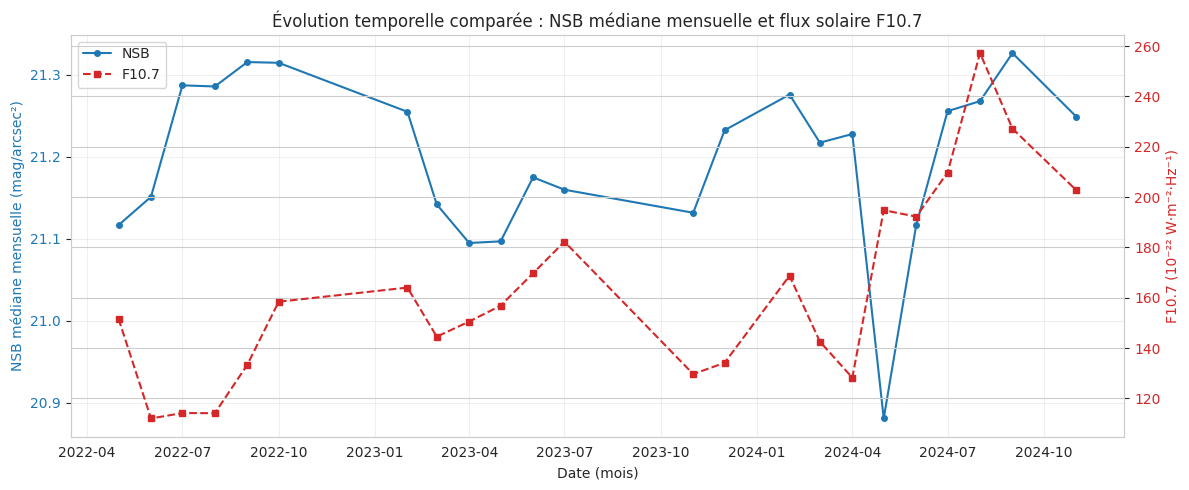

In [22]:
# Évolution temporelle comparée : NSB médiane mensuelle et flux solaire F10.7
# Vérifier que les séries mensuelles existent
try:
    # monthly_nsb_f107 et monthly_f107 ont été obtenues lors du calcul des corrélations
    # (section 9 du pipeline, bloc NSB vs F10.7)
    nsb_m = monthly_nsb_f107.dropna()
    f107_m = monthly_f107.dropna()
except NameError:
    print("⚠️ Les séries mensuelles ne sont pas définies. Exécutez d'abord la cellule de corrélation F10.7.")
    # Fallback minimal si besoin
    monthly_agg = aggregated.groupby('year_month').agg(
        median_NSB=('median_NSB', 'median'),
        F10_7_mean=('F10.7', 'mean')
    )
    nsb_m = monthly_agg['median_NSB']
    f107_m = monthly_agg['F10_7_mean']

# Aligner les dates communes
common_idx = nsb_m.index.intersection(f107_m.index)
nsb_m = nsb_m.loc[common_idx]
f107_m = f107_m.loc[common_idx]

# Création de la figure avec deux axes y
fig, ax1 = plt.subplots(figsize=(12, 5))

# Courbe NSB (axe gauche)
color1 = 'tab:blue'
ax1.set_xlabel('Date (mois)')
ax1.set_ylabel('NSB médiane mensuelle (mag/arcsec²)', color=color1)
ax1.plot(common_idx.to_timestamp(), nsb_m.values, 'o-', color=color1, linewidth=1.5, markersize=4, label='NSB')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Courbe F10.7 (axe droit)
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('F10.7 (10⁻²² W·m⁻²·Hz⁻¹)', color=color2)
ax2.plot(common_idx.to_timestamp(), f107_m.values, 's--', color=color2, linewidth=1.5, markersize=4, label='F10.7')
ax2.tick_params(axis='y', labelcolor=color2)

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Évolution temporelle comparée : NSB médiane mensuelle et flux solaire F10.7')
plt.tight_layout()
plt.savefig('figures/nsb_vs_f107_timeseries.png', dpi=150)
plt.show()

In [17]:
print(aggregated['median_NSB'].describe())

count    247.000000
mean      21.212403
std        0.149588
min       20.398855
25%       21.122612
50%       21.236328
75%       21.314850
max       21.491302
Name: median_NSB, dtype: float64


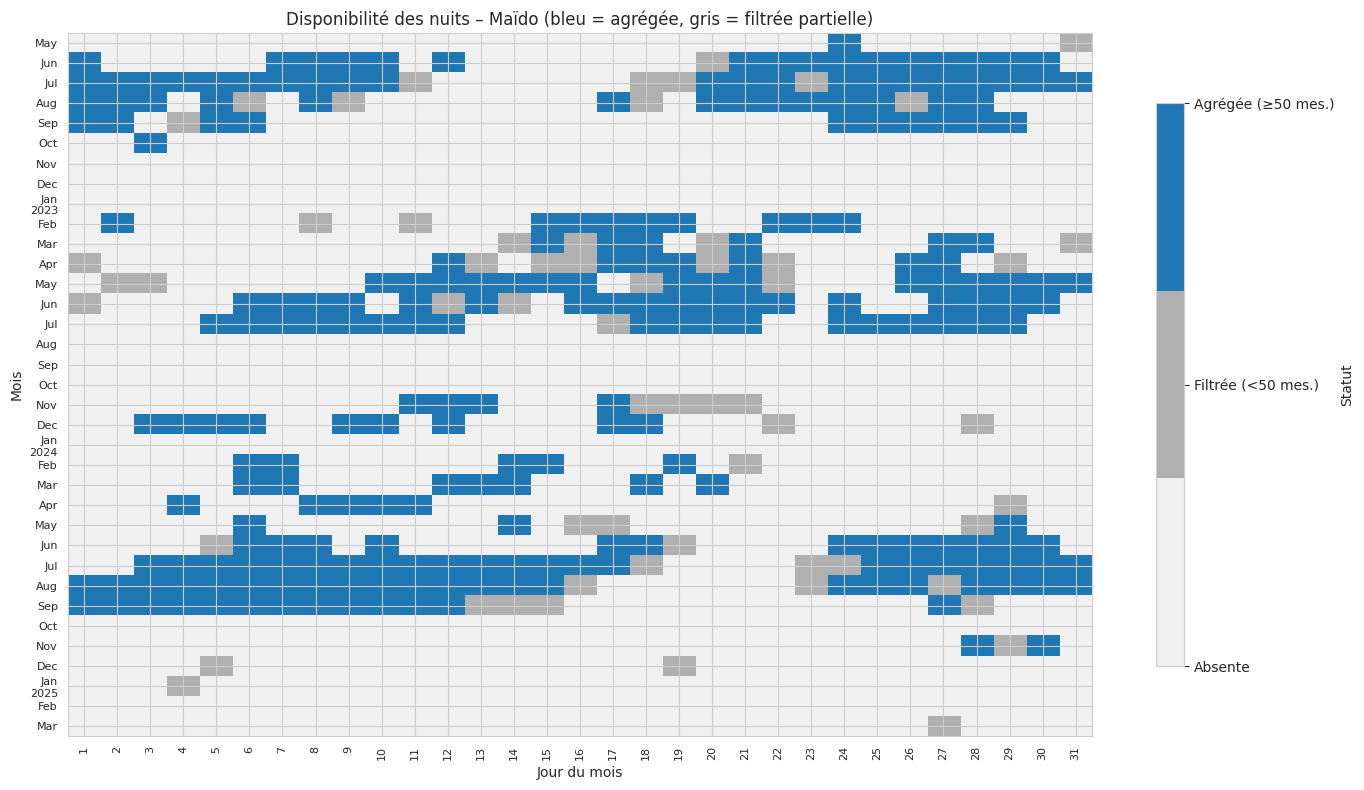

In [18]:
import calendar
# --- Préparation des données ---
# Utiliser aggregated qui contient 'night_date' (date de la nuit)
agg = aggregated.copy()
agg['date'] = pd.to_datetime(agg['night_date'])  # date de la nuit
agg['year'] = agg['date'].dt.year
agg['month'] = agg['date'].dt.month
agg['day'] = agg['date'].dt.day

# Utiliser df_filtered (chaque mesure est une ligne)
# Créer une colonne date (date de la nuit)
df_filt = df_filtered.copy()
df_filt['date'] = pd.to_datetime(df_filt['night_date'])
df_filt['year'] = df_filt['date'].dt.year
df_filt['month'] = df_filt['date'].dt.month
df_filt['day'] = df_filt['date'].dt.day

# Identifier les nuits uniques (combinaison date, night_id) si vous voulez compter chaque nuit une fois
nuits_filtrees = df_filt[['date', 'night_id']].drop_duplicates()

# Créer le calendrier basé sur la présence d'au moins une nuit ce jour
all_dates = pd.date_range(nuits_filtrees['date'].min(), nuits_filtrees['date'].max(), freq='D')
df_cal = pd.DataFrame({'date': all_dates})
df_cal['year'] = df_cal['date'].dt.year
df_cal['month'] = df_cal['date'].dt.month
df_cal['day'] = df_cal['date'].dt.day
df_cal['available'] = df_cal['date'].isin(nuits_filtrees['date']).astype(int)

calendar_matrix = df_cal.pivot_table(index=['year', 'month'], columns='day', values='available', fill_value=0)

# Créer deux ensembles de dates
dates_agregees = set(aggregated['night_date'].dropna().unique())
dates_filtrees = set(df_filt['night_date'].dropna().unique())

all_dates = pd.date_range(min(dates_filtrees), max(dates_filtrees), freq='D')
df_cal = pd.DataFrame({'date': all_dates})
df_cal['year'] = df_cal['date'].dt.year
df_cal['month'] = df_cal['date'].dt.month
df_cal['day'] = df_cal['date'].dt.day

def status(d):
    if d in dates_agregees:
        return 2   # nuit agrégée
    elif d in dates_filtrees:
        return 1   # nuit filtrée mais non agrégée
    else:
        return 0

df_cal['status'] = df_cal['date'].apply(status)

calendar_matrix = df_cal.pivot_table(index=['year', 'month'], columns='day', values='status', fill_value=0)

# Palette : 0=blanc, 1=gris clair, 2=bleu
cmap = plt.cm.colors.ListedColormap(['#f0f0f0', '#b0b0b0', '#1f77b4'])

plt.figure(figsize=(14, 8))
ax = plt.gca()
im = ax.imshow(calendar_matrix.values, aspect='auto', cmap=cmap, interpolation='nearest', vmin=0, vmax=2)
# Légende discrète
cbar = plt.colorbar(im, ticks=[0, 1, 2], label='Statut', shrink=0.8)
cbar.ax.set_yticklabels(['Absente', 'Filtrée (<50 mes.)', 'Agrégée (≥50 mes.)'])

# Étiquettes (comme avant)
ax.set_xticks(np.arange(31))
ax.set_xticklabels(np.arange(1, 32))
ax.set_xlabel('Jour du mois')
years = calendar_matrix.index.get_level_values(0)
months = calendar_matrix.index.get_level_values(1)
labels = [f"{calendar.month_abbr[m]}\n{y}" if m==1 else f"{calendar.month_abbr[m]}" for y,m in zip(years, months)]
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_ylabel('Mois')
plt.title('Disponibilité des nuits – Maïdo (bleu = agrégée, gris = filtrée partielle)')
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig('figures/calendrier_disponibilite_detail.png', dpi=150)
plt.show()

In [19]:
# Création d'un tableau de disponibilité des données par mois et par année

# Ajout des colonnes année et mois à partir de la date locale (début de nuit)
for data, label in [(df, 'brut'), (df_filtered, 'filtre')]:
    # Si night_date n'est pas déjà datetime
    data['year'] = pd.to_datetime(data['night_date']).dt.year
    data['month'] = pd.to_datetime(data['night_date']).dt.month

# Comptage des mesures par mois/année
counts_brut = df.groupby(['year', 'month']).size().reset_index(name='mesures_brutes')
counts_filt = df_filtered.groupby(['year', 'month']).size().reset_index(name='mesures_filtrees')

# Comptage des nuits (night_id unique) par mois/année
nuits_brut = df.dropna(subset=['night_id']).groupby(['year', 'month'])['night_id'].nunique().reset_index(name='nuits_brutes')
nuits_filt = df_filtered.dropna(subset=['night_id']).groupby(['year', 'month'])['night_id'].nunique().reset_index(name='nuits_filtrees')

# Fusion des quatre tableaux
tableau = counts_brut.merge(counts_filt, on=['year', 'month'], how='outer')\
                     .merge(nuits_brut, on=['year', 'month'], how='outer')\
                     .merge(nuits_filt, on=['year', 'month'], how='outer')\
                     .fillna(0).astype({'mesures_brutes':int, 'mesures_filtrees':int,
                                        'nuits_brutes':int, 'nuits_filtrees':int})

# Tri chronologique
tableau = tableau.sort_values(['year', 'month']).reset_index(drop=True)

# Ajout d'une colonne date pour affichage
tableau['mois'] = tableau.apply(lambda r: f"{int(r['year'])}-{int(r['month']):02d}", axis=1)

# Réorganisation des colonnes pour un affichage clair
tableau = tableau[['mois', 'mesures_brutes', 'mesures_filtrees', 'nuits_brutes', 'nuits_filtrees']]

# Calcul des totaux annuels (optionnel)
tableau_annuel = tableau.copy()
tableau_annuel['year'] = tableau_annuel['mois'].str[:4].astype(int)
annuel = tableau_annuel.groupby('year').sum()[['mesures_brutes', 'mesures_filtrees', 'nuits_brutes', 'nuits_filtrees']]
annuel = annuel.reset_index()

print("Tableau mensuel de disponibilité des données :")
display(tableau)
print("\nTotaux annuels :")
display(annuel)

# Sauvegarde éventuelle
tableau.to_csv('disponibilite_mensuelle.csv', index=False)
annuel.to_csv('disponibilite_annuelle.csv', index=False)

Tableau mensuel de disponibilité des données :


,mois,mesures_brutes,mesures_filtrees,nuits_brutes,nuits_filtrees
0,2022-05,497,169,8,2
1,2022-06,11783,3850,30,17
2,2022-07,18883,5930,33,26
3,2022-08,11275,3189,63,22
4,2022-09,6795,3247,20,11
5,2022-10,533,162,1,1
6,2023-01,970,0,2,0
7,2023-02,11440,2343,34,13
8,2023-03,5687,1295,66,15
9,2023-04,9749,1271,111,18



Totaux annuels :


,year,mesures_brutes,mesures_filtrees,nuits_brutes,nuits_filtrees
0,2022,49766,16547,155,79
1,2023,96675,17484,449,131
2,2024,135901,23404,305,116
3,2025,47113,6,89,2


In [20]:
#Climatologie
agg = aggregated.copy()
agg['night_date_dt'] = pd.to_datetime(agg['night_date'])
agg['year'] = agg['night_date_dt'].dt.year
agg['month'] = agg['night_date_dt'].dt.month

# Fonction pour calculer les indicateurs sur un groupe
def nsb_indicators(grp):
    nsb = grp['median_NSB']
    return pd.Series({
        'nb_nuits': len(nsb),
        'NSB_mediane': nsb.median(),
        'NSB_moyenne': nsb.mean(),
        'NSB_IQR': nsb.quantile(0.75) - nsb.quantile(0.25),
        'NSB_min': nsb.min(),
        'NSB_max': nsb.max(),
        'BZEN_moyen': grp['mean_B_ZEN'].mean(),
        'deltaT_moyen': grp['mean_deltaT'].mean()
    })

# Tableau mensuel (toutes années confondues pour la climatologie)
climato_mensuelle = agg.groupby('month').apply(nsb_indicators).reset_index()
climato_mensuelle['month_name'] = climato_mensuelle['month'].apply(
    lambda m: pd.Timestamp(2020, m, 1).strftime('%B'))
climato_mensuelle = climato_mensuelle[['month','month_name','nb_nuits','NSB_mediane','NSB_moyenne',
                                       'NSB_IQR','NSB_min','NSB_max','BZEN_moyen','deltaT_moyen']]

# Tableau annuel (chaque année séparément)
tableau_annuel = agg.groupby('year').apply(nsb_indicators).reset_index()

# Tableau mensuel par année (mois × année)
tableau_mensuel_annee = agg.groupby(['year','month']).apply(nsb_indicators).reset_index()
tableau_mensuel_annee['mois'] = tableau_mensuel_annee.apply(
    lambda r: f"{int(r['year'])}-{int(r['month']):02d}", axis=1)
tableau_mensuel_annee = tableau_mensuel_annee[['mois','nb_nuits','NSB_mediane','NSB_moyenne',
                                               'NSB_IQR','NSB_min','NSB_max','BZEN_moyen','deltaT_moyen']]

# Affichage
print("=== Climatologie mensuelle (toutes années confondues) ===")
display(climato_mensuelle)
print("\n=== Tableau annuel ===")
display(tableau_annuel)
print("\n=== Tableau mensuel par année (extrait des premières lignes) ===")
display(tableau_mensuel_annee.head(20))

# Export CSV
climato_mensuelle.to_csv('climatologie_mensuelle.csv', index=False)
tableau_annuel.to_csv('indicateurs_annuels.csv', index=False)
tableau_mensuel_annee.to_csv('indicateurs_mensuels_par_annee.csv', index=False)

=== Climatologie mensuelle (toutes années confondues) ===


,month,month_name,nb_nuits,NSB_mediane,NSB_moyenne,NSB_IQR,NSB_min,NSB_max,BZEN_moyen,deltaT_moyen
0,2,February,15.0,21.236328,21.263487,0.103481,21.139755,21.491302,33.666958,27.611785
1,3,March,14.0,21.205408,21.179767,0.155383,20.989016,21.288040,34.281200,25.753223
2,4,April,12.0,21.151430,21.150462,0.093491,20.930313,21.314850,33.831953,23.884654
3,5,May,21.0,21.072575,21.067187,0.130445,20.839020,21.261877,12.151883,27.410993
4,6,June,48.0,21.163105,21.150148,0.153689,20.398855,21.429243,-5.572278,38.593589
5,7,July,61.0,21.288040,21.238451,0.202584,20.892870,21.459830,-34.215403,39.464724
6,8,August,37.0,21.288040,21.275325,0.117225,21.094510,21.459830,-57.098584,39.894491
7,9,September,23.0,21.342339,21.321915,0.137619,20.949530,21.491302,-62.376944,34.588891
8,10,October,1.0,21.314850,21.314850,0.000000,21.314850,21.314850,-48.667038,34.383642
9,11,November,6.0,21.188042,21.171007,0.132877,21.009310,21.261877,-48.595639,24.786760



=== Tableau annuel ===


,year,nb_nuits,NSB_mediane,NSB_moyenne,NSB_IQR,NSB_min,NSB_max,BZEN_moyen,deltaT_moyen
0,2022,64.0,21.261877,21.255245,0.155371,20.911430,21.459830,-40.782515,45.890835
1,2023,89.0,21.163105,21.160247,0.163753,20.930313,21.399496,-3.084724,28.522939
2,2024,94.0,21.274958,21.232617,0.155371,20.398855,21.491302,-22.436568,32.822577



=== Tableau mensuel par année (extrait des premières lignes) ===


,mois,nb_nuits,NSB_mediane,NSB_moyenne,NSB_IQR,NSB_min,NSB_max,BZEN_moyen,deltaT_moyen
0,2022-05,1.0,21.116898,21.116898,0.000000,21.116898,21.116898,30.783790,41.750526
1,2022-06,16.0,21.163105,21.151399,0.111791,20.911430,21.314850,-10.446153,47.357245
2,2022-07,21.0,21.314850,21.287363,0.080462,20.930313,21.429243,-45.025325,46.058694
3,2022-08,15.0,21.314850,21.285972,0.086364,21.094510,21.459830,-57.314038,44.888486
4,2022-09,10.0,21.288363,21.315734,0.149542,21.186968,21.459830,-61.981690,46.260350
5,2022-10,1.0,21.314850,21.314850,0.000000,21.314850,21.314850,-48.667038,34.383642
6,2023-02,9.0,21.236328,21.255069,0.078522,21.163105,21.370540,32.669457,29.548585
7,2023-03,7.0,21.139755,21.142102,0.121866,20.989016,21.288040,34.602376,25.155418
8,2023-04,7.0,21.116898,21.095088,0.088472,20.930313,21.236328,33.005419,23.749163
9,2023-05,17.0,21.072575,21.097101,0.088680,20.949530,21.261877,9.307044,26.384004


In [21]:
# Tableau des nuits extrêmes (brillantes et sombres) pour chaque mois/année
# S'assurer que la colonne night_date est bien datetime
agg = aggregated.copy()
agg['night_date_dt'] = pd.to_datetime(agg['night_date'])
agg['year'] = agg['night_date_dt'].dt.year
agg['month'] = agg['night_date_dt'].dt.month

# Index de la nuit la plus brillante (min NSB) et la plus sombre (max NSB) par mois/année
idx_min = agg.groupby(['year', 'month'])['median_NSB'].idxmin()
idx_max = agg.groupby(['year', 'month'])['median_NSB'].idxmax()

brightest = agg.loc[idx_min][['night_date', 'year', 'month', 'median_NSB', 'mean_B_ZEN', 'mean_deltaT', 'n_measures']].copy()
brightest['type'] = 'brillante (min NSB)'

darkest   = agg.loc[idx_max][['night_date', 'year', 'month', 'median_NSB', 'mean_B_ZEN', 'mean_deltaT', 'n_measures']].copy()
darkest['type'] = 'sombre (max NSB)'

extremes = pd.concat([brightest, darkest]).sort_values(['year', 'month', 'type'])

print("Tableau des nuits extrêmes (brillantes et sombres) pour chaque mois/année :")
display(extremes)

# Sauvegarde
extremes.to_csv('nuits_extremes_par_mois.csv', index=False)

Tableau des nuits extrêmes (brillantes et sombres) pour chaque mois/année :


,night_date,year,month,median_NSB,mean_B_ZEN,mean_deltaT,n_measures,type
night_id,,,,,,,,
0.0,2022-05-24,2022,5,21.116898,30.783790,41.750526,133,brillante (min NSB)
0.0,2022-05-24,2022,5,21.116898,30.783790,41.750526,133,sombre (max NSB)
28.0,2022-06-21,2022,6,20.911430,41.495662,58.109815,54,brillante (min NSB)
35.0,2022-06-28,2022,6,21.314850,-31.756764,47.431081,296,sombre (max NSB)
57.0,2022-07-20,2022,7,20.930313,14.371400,49.610484,124,brillante (min NSB)
38.0,2022-07-01,2022,7,21.429243,-21.845367,48.751395,387,sombre (max NSB)
126.0,2022-08-27,2022,8,21.094510,-30.956631,41.859623,53,brillante (min NSB)
117.0,2022-08-23,2022,8,21.459830,-65.800557,49.983244,336,sombre (max NSB)
153.0,2022-09-29,2022,9,21.186968,-63.855656,38.584197,417,brillante (min NSB)
